# ✈️ Flight Price Prediction — End-to-End Machine Learning Pipeline

| Field | Details |
|---|---|
| *Name* | Hamza Siddiqui |
| *Project ID* | PRCP-1025-FlightPricePrediction |
| *Project Type* | Supervised Learning — Regression |
| *Target Variable* | Price |
| *Dataset Size* | 10,683 rows × 11 columns |

**Problem:**
Flight ticket prices can be something hard to guess, today we might see a price, check out the price of the same flight tomorrow, it will be a different story. We might have often heard travelers saying that flight ticket prices are so unpredictable. That’s why we will try to use machine learning to solve this problem. This can help airlines by predicting what prices they can maintain.

**Goal:**
Build a machine learning model that predicts flight ticket prices based on airline, route, duration, stops, etc

# Import Libraries 

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style='whitegrid')
import warnings
warnings.filterwarnings("ignore")

In [79]:
data = pd.read_excel("C:\\Users\\hamza\\OneDrive\\Desktop\\PRCP-1025-flight-price\\Flight_Fare.xlsx")

In [80]:
data.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [81]:
data.shape

(10683, 11)

**Dataset Overview:** 10,683 flight records with 11 columns. Key features include Airline, Source, Destination, Duration, Total_Stops, and the target variable Price.

In [82]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


Almost all columns are `object` type — only `Price` is numeric. Significant feature engineering and encoding required before modeling.

In [83]:
data.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


**Key Statistics — Price:**
- Mean: ₹9,087 | Median: ₹8,372
- Min: ₹1,759 | Max: ₹79,512
- High std (₹4,611) = large price variability
- Gap between 75th percentile and max → outliers from Business class tickets

# Data Cleaning

In [84]:
data.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

- **Missing Values:** Only 1 null in Route and Total_Stops (same row). Less than 0.01% of data — safe to drop.

In [85]:
data.dropna(inplace=True)

I checked null values and removed rows where Route and Total_Stops were missing because they were very few.

In [86]:
data.duplicated().sum()

np.int64(220)

In [87]:
data[data.duplicated].head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,7303


In [88]:
# Group and count duplicates
duplicate_summary = data.groupby(['Airline', 'Date_of_Journey', 'Source', 'Destination','Route','Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops','Additional_Info', 'Price']).size().reset_index(name='Count')
duplicate_summary[duplicate_summary['Count'] > 1].sort_values(by='Count', ascending=False).head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Count
966,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392,3
809,Air India,15/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 16 May,21h 15m,2 stops,No info,11281,3
508,Air India,1/05/2019,Kolkata,Banglore,CCU → DEL → COK → BLR,10:00,13:45 02 May,27h 45m,2 stops,No info,15164,3
1338,Air India,24/06/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 25 Jun,21h 15m,2 stops,No info,9181,3
4757,Jet Airways,1/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 02 Jun,22h 55m,2 stops,No info,13014,3


- We checked for duplicate records to ensure data integrity. Exact duplicates (all columns identical) were removed.”
- “Flights with the same source and destination but different airlines, routes, or prices were retained, as they represent genuine market options rather than data errors.”


## EDA (Exploratory Data Analysis)

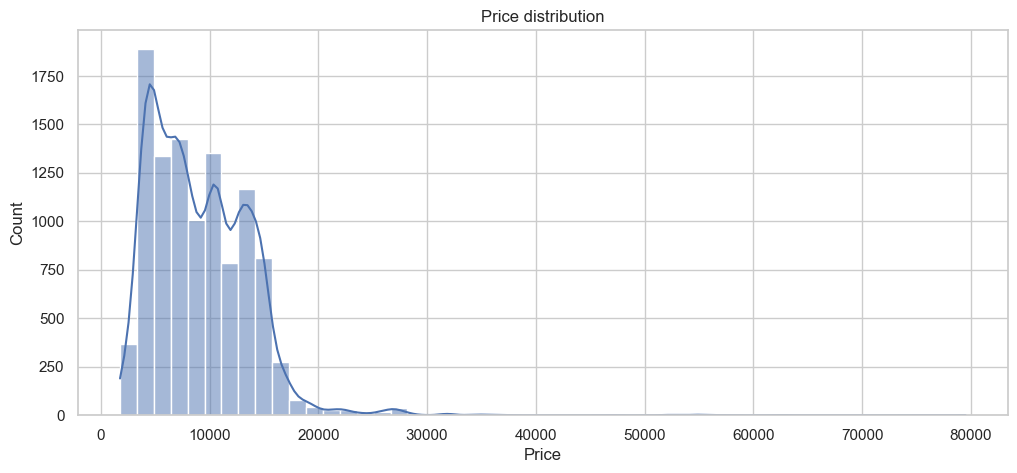

In [89]:
sns.histplot(data['Price'],bins=50,kde=True)
plt.title("Price distribution")
plt.show()

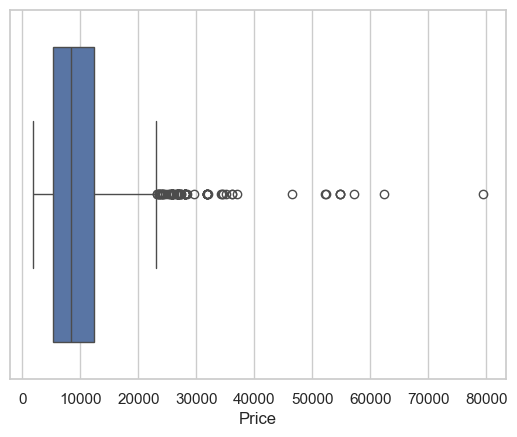

In [90]:
sns.boxplot(x=data['Price'])
plt.show()

- Most ticket prices are in mid range
- Few Expensive flights (Outliers)

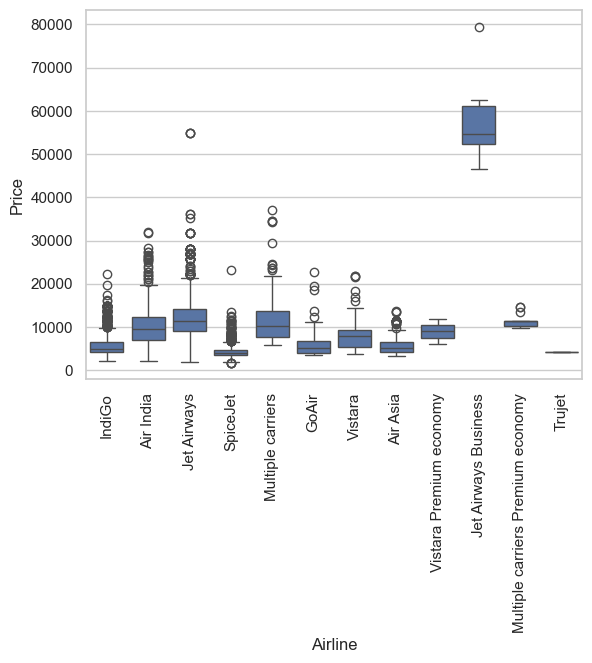

In [91]:
sns.boxplot(x='Airline', y='Price', data=data)
plt.xticks(rotation=90)
plt.show()

- **Jet Airways Business** tickets are expensive

- SpiceJet and Trujet cheaper flights

- Airline vs Average Price

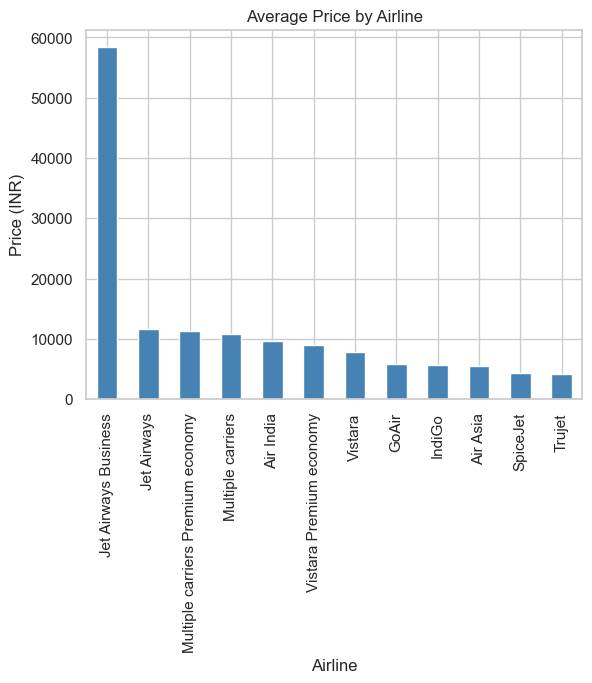

In [97]:
data.groupby("Airline")["Price"].mean().sort_values(ascending=False).plot(kind="bar", color="steelblue")
plt.title("Average Price by Airline")
plt.ylabel("Price (INR)")
plt.xticks(rotation=90)
plt.show()

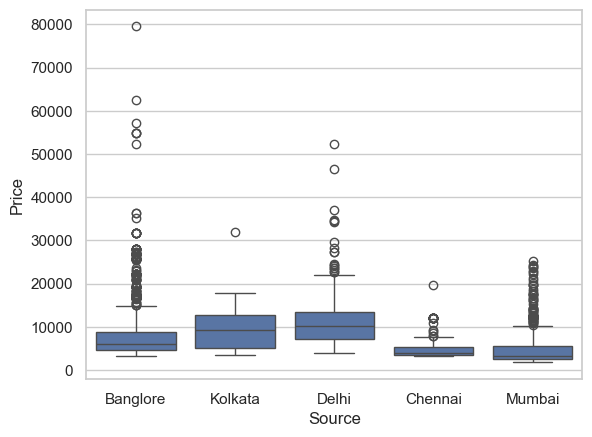

In [15]:
sns.boxplot(x='Source', y='Price', data=data)
plt.show()

- Source vs Average Price

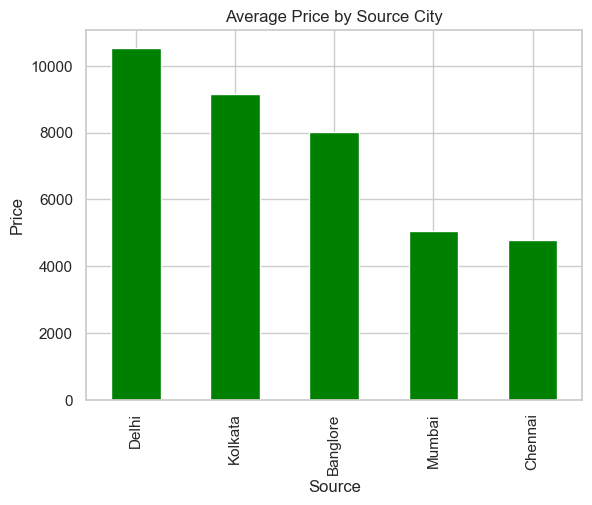

In [100]:
data.groupby("Source")["Price"].mean().sort_values(ascending=False).plot(kind="bar", color="green")
plt.title("Average Price by Source City")
plt.ylabel("Price")
plt.show()

Delhi and Kolkata cities have: Higher demand

But Flights from **Banglore** and **Delhi** is costly.

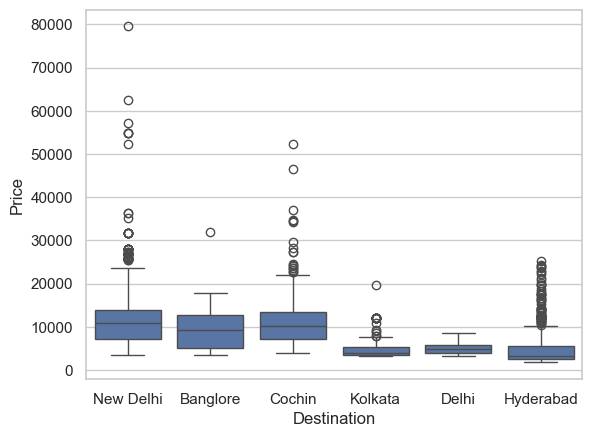

In [16]:
sns.boxplot(x='Destination', y='Price', data=data)
plt.show()

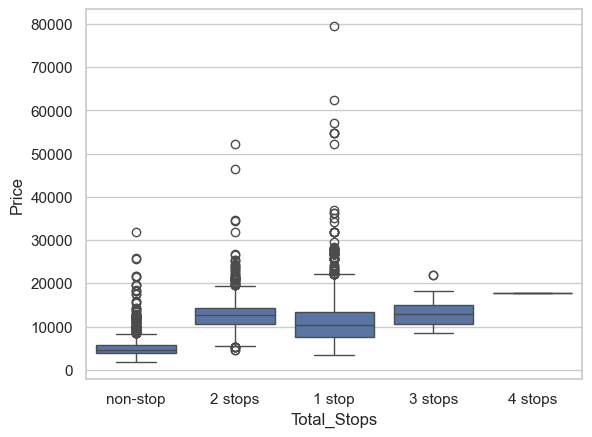

In [17]:
sns.boxplot(x=data["Total_Stops"],y=data["Price"])
plt.show()

- Total Stops vs Average Price

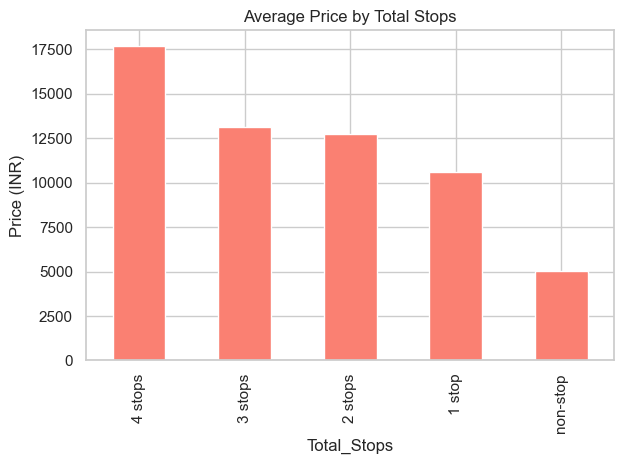

In [99]:
data.groupby("Total_Stops")["Price"].mean().sort_values(ascending=False).plot(kind="bar", color="salmon")
plt.title("Average Price by Total Stops")
plt.ylabel("Price (INR)")
plt.tight_layout()
plt.show()

 ### 1 stops → usually Higher flight price📉
 Most Flights are 1 stop and non-stops Few are 2 stops and 3 stops

## Task 1 — Data Analysis Report

**Key Findings from EDA:**
- Jet Airways Business class has the highest average price
- Price distribution is right-skewed due to premium flights.
- Flights with more stops tend to cost more
- Delhi is the most expensive source city
- Summer months (May-June) show higher pricing trends

# Feature Engineering

Raw string columns are parsed into numeric features. Each transformation is explained below.

In [18]:
data['Date_of_Journey'].dtypes

dtype('O')

date_of_journey column is showing object data types it should be Date_time
machine learning model understand only numerical data so we convert into date_time format
and extract Date and Month
#### Convert Date_of_Journey to datetime

In [19]:
data['Date_of_Journey']=pd.to_datetime(data.Date_of_Journey,format="%d/%m/%Y")

- Extracting day, month and year from date_of_journey

In [20]:
data['Journey_day']=pd.to_datetime(data.Date_of_Journey,format="%d/%m/%Y").dt.day
data['Journey_month']=pd.to_datetime(data.Date_of_Journey,format="%d/%m/%Y").dt.month

Extract the Week and weekends

In [21]:
data["day_of_week"]=data["Date_of_Journey"].dt.day_name()

- Creating an **Is_Weekend** flag (0 or 1) based on the date of journey.

In [22]:
data['Is_Weekend'] = data["Date_of_Journey"].dt.dayofweek.apply(lambda x: 1 if x>=5 else 0)

In [23]:
data.drop('Date_of_Journey',axis=1,inplace=True)

In [24]:
data.sample()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Journey_day,Journey_month,day_of_week,Is_Weekend
2714,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,06:00,12:35,6h 35m,1 stop,No info,12524,24,6,Monday,0


- Convert Departure Time to datetime and extract hour/minute

In [25]:
data["Dep_Time"]=pd.to_datetime(data['Dep_Time'],format="%H:%M")

- Dep_Time Extraction & Part of Day

In [26]:
data["Dep_hour"]=data["Dep_Time"].dt.hour
data["Dep_min"]=data["Dep_Time"].dt.minute

In [27]:
def get_part_of_day(hour):
    if 5 <= hour <12: return "Morning"
    elif 12 <= hour <17: return "AfterNoon"
    elif 17 <= hour <21: return "Evining"
    else: return "Night"

In [28]:
data['Part_of_Day'] = data['Dep_hour'].apply(get_part_of_day)

In [29]:
data.drop('Dep_Time',axis=1,inplace=True)

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Source           10682 non-null  object
 2   Destination      10682 non-null  object
 3   Route            10682 non-null  object
 4   Arrival_Time     10682 non-null  object
 5   Duration         10682 non-null  object
 6   Total_Stops      10682 non-null  object
 7   Additional_Info  10682 non-null  object
 8   Price            10682 non-null  int64 
 9   Journey_day      10682 non-null  int32 
 10  Journey_month    10682 non-null  int32 
 11  day_of_week      10682 non-null  object
 12  Is_Weekend       10682 non-null  int64 
 13  Dep_hour         10682 non-null  int32 
 14  Dep_min          10682 non-null  int32 
 15  Part_of_Day      10682 non-null  object
dtypes: int32(4), int64(2), object(10)
memory usage: 1.2+ MB


- Convert Arrival Time to datetime

In [31]:
data["Arrival_Time"]=pd.to_datetime(data["Arrival_Time"],errors="coerce")

In [32]:
data["Arrivel_hour"]=data["Arrival_Time"].dt.hour
data["Arrivel_minute"]=data["Arrival_Time"].dt.minute 

In [33]:
data.drop('Arrival_Time',axis=1,inplace=True)

- Date_of_Journey, Dep_Time, and Arrival_Time into proper datetime objects. This allows us to extract granular features such as day, month, hour, and minutes.
  
- Arrival times contained mixed formats (some with dates, some without). We used errors='coerce' to handle inconsistencies gracefully, ensuring missing values are flagged for later imputation.

- **Duration Column Cleaning**

In [34]:
data['Duration_hours'] = data['Duration'].str.extract('(\d+)h').fillna(0).astype(int)
data['Duration_mins'] = data['Duration'].str.extract('(\d+)m').fillna(0).astype(int)

In [35]:
data["Duration_minutes"] = (data['Duration_hours']*60) + data['Duration_mins']

In [36]:
data.drop("Duration",axis=1, inplace=True)

In [37]:
data.drop("Duration_hours",axis=1, inplace=True)
data.drop("Duration_mins",axis=1, inplace=True)

**Duration** was stored as mixed strings like `'2h 50m'` or `'19h'`. Regex handles both cases. Total minutes gives model one continuous variable — longer flight = usually more expensive.

In [38]:
data['Route_Complexity'] = data['Route'].str.split('→').str.len()

In [39]:
data.Route_Complexity

0        2
1        4
2        4
3        3
4        3
        ..
10678    2
10679    2
10680    2
10681    2
10682    4
Name: Route_Complexity, Length: 10682, dtype: int64

In [40]:
data.drop("Route",axis=1,inplace=True)

The Route column is text, but the number of cities (arrows →) tells a story. A route with 4 cities is objectively more complex and usually more expensive than a direct flight. We extract this as Route_Complexity to give the model a numerical weight for the "length" of the journey.

Short Summary:
- Extracted day and month from journey date
- Converted Dep time into hours and minutes
- Transformed duration into numeric format Total_Duration min

---
# Encoding 
##### Categorical Variables

### Encoding Strategy

| Column | Encoding | Reason |
|---|---|---|
| `Total_Stops` | **Ordinal** | Natural order: non-stop < 1 stop < 2 stops |
| `Airline` | **One-Hot** | No inherent order — nominal |
| `Source` | **One-Hot** | Nominal |
| `Destination` | **One-Hot** | Nominal |
| `Additional_Info` | **One-Hot** | Nominal |
| `day_of_week` | **One-Hot** | Nominal |
| `Part_of_Day` | **One-Hot** | Nominal bins |

In [41]:
cat_col = data.select_dtypes(include="O")

Checking the unique categoriesc in each object column 

In [42]:
for col in cat_col:
    print(col,data[col].nunique())
    print("-"*30)

Airline 12
------------------------------
Source 5
------------------------------
Destination 6
------------------------------
Total_Stops 5
------------------------------
Additional_Info 10
------------------------------
day_of_week 7
------------------------------
Part_of_Day 4
------------------------------


In [43]:
for col in cat_col:
    print(data[col].value_counts())
    print("-"*50)

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1751
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64
--------------------------------------------------
Source
Delhi       4536
Kolkata     2871
Banglore    2197
Mumbai       697
Chennai      381
Name: count, dtype: int64
--------------------------------------------------
Destination
Cochin       4536
Banglore     2871
Delhi        1265
New Delhi     932
Hyderabad     697
Kolkata       381
Name: count, dtype: int64
--------------------------------------------------
Total_Stops
1 stop      5625
non-stop    3491

Only total_stops column applying Ordinal encoding

# Ordinal Encoding (Total_Stops)

In [44]:
data['Total_Stops'] = data["Total_Stops"].map({"non-stop":0,'1 stop':1,"2 stops":2, '3 stops':3,'4 stops':4})

**Why Ordinal?** Total_Stops has natural rank — 2 stops is objectively more complex than 1. Ordinal encoding preserves this math relationship.

In [45]:
data.Total_Stops

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Total_Stops, Length: 10682, dtype: int64

- Total_Stops
im using **Ordinal Encoding** in **Total Stops** whene categories have a natural order.

For example, Total_Stops has a rank: "non-stop" (0) is less than "1 stop" (1), which is less than "2 stops" (2).

# OneHotEncoding

In [46]:
data = pd.get_dummies(data,drop_first=True).astype(int)

**Why One-Hot?** Airline, Source, Destination have no natural order. `drop_first=True` avoids multicollinearity (dummy variable trap).

In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 49 columns):
 #   Column                                        Non-Null Count  Dtype
---  ------                                        --------------  -----
 0   Total_Stops                                   10682 non-null  int64
 1   Price                                         10682 non-null  int64
 2   Journey_day                                   10682 non-null  int64
 3   Journey_month                                 10682 non-null  int64
 4   Is_Weekend                                    10682 non-null  int64
 5   Dep_hour                                      10682 non-null  int64
 6   Dep_min                                       10682 non-null  int64
 7   Arrivel_hour                                  10682 non-null  int64
 8   Arrivel_minute                                10682 non-null  int64
 9   Duration_minutes                              10682 non-null  int64
 10  Route_Complexit

In [48]:
corr = data.corr(numeric_only=True)
corr['Price'].sort_values(ascending=False).head(15)

Price                                          1.000000
Route_Complexity                               0.603897
Total_Stops                                    0.603897
Duration_minutes                               0.506480
Airline_Jet Airways                            0.416124
Destination_Cochin                             0.270676
Source_Delhi                                   0.270676
Airline_Jet Airways Business                   0.253303
Additional_Info_Business class                 0.200307
Destination_New Delhi                          0.189777
Airline_Multiple carriers                      0.139793
Airline_Air India                              0.050432
Additional_Info_Change airports                0.042834
Additional_Info_In-flight meal not included    0.039810
day_of_week_Sunday                             0.038028
Name: Price, dtype: float64

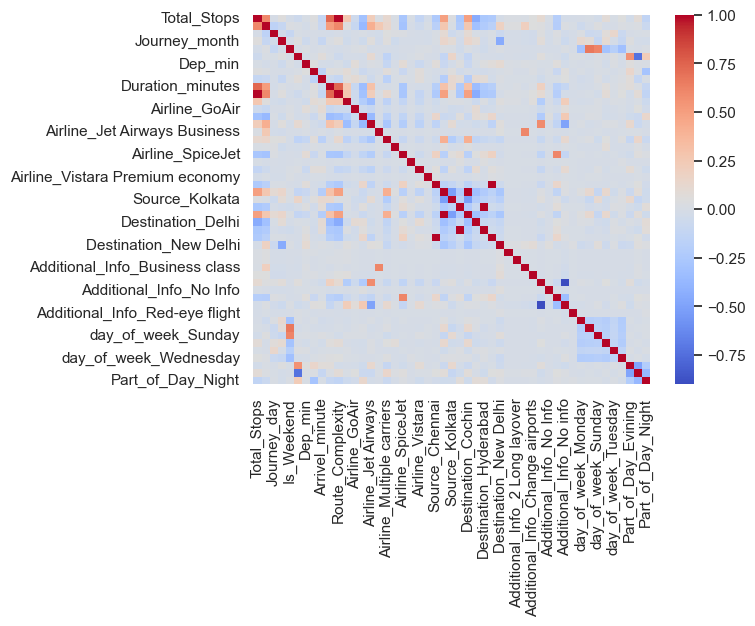

In [49]:
sns.heatmap(corr,cmap="coolwarm")
plt.show()

# Model building

In [50]:
X=data.drop("Price",axis=1)
y=data['Price']

In [51]:
X.head()

,Total_Stops,Journey_day,Journey_month,Is_Weekend,Dep_hour,Dep_min,Arrivel_hour,Arrivel_minute,Duration_minutes,Route_Complexity,...,Additional_Info_Red-eye flight,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,Part_of_Day_Evining,Part_of_Day_Morning,Part_of_Day_Night
0,0,24,3,1,22,20,1,10,170,2,...,0,0,0,1,0,0,0,0,0,1
1,2,1,5,0,5,50,13,15,445,4,...,0,0,0,0,0,0,1,0,1,0
2,2,9,6,1,9,25,4,25,1140,4,...,0,0,0,1,0,0,0,0,1,0
3,1,12,5,1,18,5,23,30,325,3,...,0,0,0,1,0,0,0,1,0,0
4,1,1,3,0,16,50,21,35,285,3,...,0,0,0,0,0,0,0,0,0,0


In [52]:
y

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10678     4107
10679     4145
10680     7229
10681    12648
10682    11753
Name: Price, Length: 10682, dtype: int64

## train_test_split

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [76]:
print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (8545, 48)
Test size : (2137, 48)


# Building Models

In [54]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300,random_state=42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)
print("r2_score",r2_score(y_test,y_pred_rf))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred_rf)))

r2_score 0.908257736992987
RMSE 1406.4678603733823


In [55]:
from sklearn.ensemble import ExtraTreesRegressor
etr=ExtraTreesRegressor(n_estimators=500,random_state=42)
etr.fit(X_train,y_train)
pred_etr = etr.predict(X_test)
print("r2 :", r2_score(y_test,pred_etr))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_etr)))

r2 : 0.915966886225362
RMSE: 1346.078278668607


In [56]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators=500,random_state=42)
gbr.fit(X_train,y_train)
pred_gb=gbr.predict(X_test)
print("r2 :", r2_score(y_test,pred_gb))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_gb)))

r2 : 0.8850583395045317
RMSE: 1574.2866821503535


In [57]:
from xgboost import XGBRegressor
xgb = XGBRegressor(random_state=42)
xgb.fit(X_train,y_train)
pred_xgb = xgb.predict(X_test)
print("r2:",r2_score(y_test,pred_xgb))
print("RMSE:",np.sqrt(mean_squared_error(y_test,pred_xgb)))

r2: 0.903315544128418
RMSE: 1443.8545200261694


In [58]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor()
dt.fit(X_train,y_train)
pred_dt=dt.predict(X_test)
print("r2",r2_score(y_test,pred_dt))

r2 0.8927702175887737


# Model Evalution

In [59]:
baseline_dict = pd.DataFrame({
    "Model": ["Random Forest", "Extra Trees","Gradient Boosting",
              "XGBoost","Decision Tree"],
    "R2 Score": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, pred_etr),
        r2_score(y_test, pred_gb),
        r2_score(y_test, pred_xgb),
        r2_score(y_test, pred_dt)],
    "RMSE":[
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, pred_etr)),
        np.sqrt(mean_squared_error(y_test, pred_gb)),
        np.sqrt(mean_squared_error(y_test, pred_xgb)),
        np.sqrt(mean_squared_error(y_test, pred_dt))]
})
baseline_df = baseline_dict.sort_values("R2 Score", ascending=False).reset_index(drop=True)
baseline_df

,Model,R2 Score,RMSE
0,Extra Trees,0.915967,1346.078279
1,Random Forest,0.908258,1406.467860
2,XGBoost,0.903316,1443.854520
3,Decision Tree,0.892770,1520.557335
4,Gradient Boosting,0.885058,1574.286682


**Observation:**
- **Extra Trees** is the best performing baseline model with **R2 of 0.916**
  and lowest RMSE of 1346, meaning predictions are closest to actual prices.
- Random Forest and XGBoost are close behind — all three are strong
  ensemble models suitable for this regression task.
- Decision Tree is the weakest model as it tends to overfit
  without any

## ExtraTrees Regression Perform Better Performance

# Hyperparameter Tuning
### Extra Tree Tuning:

In [60]:
from sklearn.model_selection import RandomizedSearchCV
etr = ExtraTreesRegressor()
param_grid = {
    "n_estimators": [200, 300, 500, 800],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}
random_search_etr = RandomizedSearchCV(
    etr,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    scoring="r2",
    verbose=2,
    random_state=42,
    n_jobs=-1
)
random_search_etr.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=ExtraTreesRegressor(), n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 500, 800]},
                   random_state=42, scoring='r2', verbose=2)

In [61]:
best_etr  = random_search_etr.best_estimator_
pred_etr_tuned  = best_etr.predict(X_test)
print("R2 Score",r2_score(y_test, pred_etr_tuned))
print("MAE",mean_absolute_error(y_test, pred_etr_tuned))
print("RMSE",np.sqrt(mean_squared_error(y_test, pred_etr_tuned)))
print(f"Best Params: {random_search_etr.best_params_}")

R2 Score 0.922675931097541
MAE 598.1606400636169
RMSE 1291.2265211372437
Best Params: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20}


**Observation:**
- After tuning, Extra Trees R2 improved from 0.916 to 0.923.
- Best parameters selected: 800 trees, max depth 20, min samples leaf 2.
- RMSE also reduced from 1346 to 1290 — predictions are more accurate.

# Hyperparameter Tuning Random Forest 

In [62]:
rf = RandomForestRegressor()

param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
rf_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(), n_iter=20,
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [200, 300, 500, 700]},
                   random_state=42, verbose=2)

## Best RF Model

In [63]:
best_rf = rf_random.best_estimator_
pred_rf_tuned=best_rf.predict(X_test)
print("Tuned RF r2 :",r2_score(y_test,pred_rf_tuned))

Tuned RF r2 : 0.896772731868177


**Observation:**
- Random Forest tuned R2 is 0.896 which is slightly lower
  than its baseline score of 0.908.
- This means tuning did not help Random Forest in this case.
- Extra Trees tuning worked better — R2 improved from 0.916 to 0.923.

In [64]:
param_grid_gbr = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
gbr_random = RandomizedSearchCV(
    gbr,
    param_distributions=param_grid_gbr,
    n_iter=20,
    cv=5,
    scoring="r2",
    verbose=2,
    random_state=42,
    n_jobs=-1
)
gbr_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=GradientBoostingRegressor(n_estimators=500,
                                                       random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='r2', verbose=2)

In [65]:
best_gbr = gbr_random.best_estimator_
pred_gbr_tuned = best_gbr.predict(X_test)
print("R2 score",r2_score(y_test,pred_gbr_tuned))

R2 score 0.9008372454858078


**Observation:**
- Gradient Boosting tuned R2 is 0.900 which is slightly
  better than its baseline score of 0.885.
- Tuning helped GBR improve but it is still weaker
  than Extra Trees tuned (0.923).

## XGBoost Tuning

In [66]:
xgb = XGBRegressor()
param_grid_xgb = {
    "n_estimators": [300, 500, 700],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}
xgb_random = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid_xgb,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)
xgb_random.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.6, 0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 5, 7, 10],
                                        'n_estimators': [300, 500, 700],
                                        'subsample': [0.6, 0.8, 1.0]},
                   random_state=42, verbose=2)

In [67]:
best_xgb = xgb_random.best_estimator_
pred_xgb_tuned =best_xgb.predict(X_test)
print("Tuned XGB R2 :",r2_score(y_test,pred_xgb_tuned))

Tuned XGB R2 : 0.9175649881362915


**Observation:**
- XGBoost tuned R2 is 0.917, better than its baseline of 0.903.
- Tuning improved XGBoost performance significantly.

# Model Comparison

In [68]:
tuned_df = pd.DataFrame({
    "Model": ["Random Forest Tuned", "Extra Trees Tuned",
              "Gradient Boosting Tuned", "XGBoost Tuned"],
    "R2 Score": [
        r2_score(y_test, pred_rf_tuned),
        r2_score(y_test, pred_etr_tuned),
        r2_score(y_test, pred_gbr_tuned),
        r2_score(y_test, pred_xgb_tuned)
    ],
    "MAE": [
        mean_absolute_error(y_test, pred_rf_tuned),
        mean_absolute_error(y_test, pred_etr_tuned),
        mean_absolute_error(y_test, pred_gbr_tuned),
        mean_absolute_error(y_test, pred_xgb_tuned)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, pred_rf_tuned)),
        np.sqrt(mean_squared_error(y_test, pred_etr_tuned)),
        np.sqrt(mean_squared_error(y_test, pred_gbr_tuned)),
        np.sqrt(mean_squared_error(y_test, pred_xgb_tuned))
    ]
})
tuned_df = tuned_df.sort_values("R2 Score", ascending=False).reset_index(drop=True)
tuned_df

,Model,R2 Score,MAE,RMSE
0,Extra Trees Tuned,0.922676,598.160640,1291.226521
1,XGBoost Tuned,0.917565,615.299438,1333.217537
2,Gradient Boosting Tuned,0.900837,689.644340,1462.242421
3,Random Forest Tuned,0.896773,834.601388,1491.908901


## Model Comparison Report

| Model | R2 Score | RMSE |
|---|---|---|
| Extra Trees Tuned | 0.923 | 1290 |
| XGBoost Tuned | 0.917 | 1333 |
| Gradient Boosting Tuned | 0.900 | 1462 |
| Random Forest Tuned | 0.896 | 1493 |

**Recommended Model for Production: Extra Trees Tuned**

Reason: Highest R2 score of 0.923 means model correctly
explains 92.3% of price variance. Lowest RMSE of 1290
means average prediction error is only Rs 1,290 per ticket.
Cross Validation score of 0.907 confirms model is stable
and generalizes well to new unseen data.

**Observation:**
- Extra Trees Tuned is the best model with R2 of 0.923 and
  lowest RMSE of 1290 among all tuned models.
- XGBoost Tuned is close second with R2 of 0.917.
- Random Forest Tuned actually performed worse than its baseline
  — tuning did not help RF in this case.
- Gradient Boosting improved after tuning but still ranks last.
- We will select Extra Trees Tuned as our final model.

# Cross Validation
- Extra Trees:

In [69]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_etr, X, y, cv=5, scoring="r2")

print("CV Scores :", [round(s, 4) for s in cv_scores])
print("Mean R2   :", round(cv_scores.mean(), 4))
print("Std       :", round(cv_scores.std(), 4))

CV Scores : [np.float64(0.9023), np.float64(0.8998), np.float64(0.9191), np.float64(0.9092), np.float64(0.9103)]
Mean R2   : 0.9081
Std       : 0.0068


**Observation:**
- Mean CV R2 of 0.90 shows model is stable and consistent.
- Low std deviation confirms model is not overfitting.

In [70]:
final_df = pd.concat([baseline_df, tuned_df], ignore_index=True)
final_df = final_df.sort_values("R2 Score", ascending=False).reset_index(drop=True)
final_df

,Model,R2 Score,RMSE,MAE
0,Extra Trees Tuned,0.922676,1291.226521,598.160640
1,XGBoost Tuned,0.917565,1333.217537,615.299438
2,Extra Trees,0.915967,1346.078279,NaN
3,Random Forest,0.908258,1406.467860,NaN
4,XGBoost,0.903316,1443.854520,NaN
5,Gradient Boosting Tuned,0.900837,1462.242421,689.644340
6,Random Forest Tuned,0.896773,1491.908901,834.601388
7,Decision Tree,0.892770,1520.557335,NaN
8,Gradient Boosting,0.885058,1574.286682,NaN


**Observation:**
- Extra Trees Tuned is the best model overall.
- Tuning improved ETR and XGBoost significantly.
- RF tuning did not help — baseline RF was better.

# Feature Importance

In [71]:
feat_imp = pd.Series(best_etr.feature_importances_,index=X.columns).sort_values(ascending=False).head(10)

## Final Model Selection

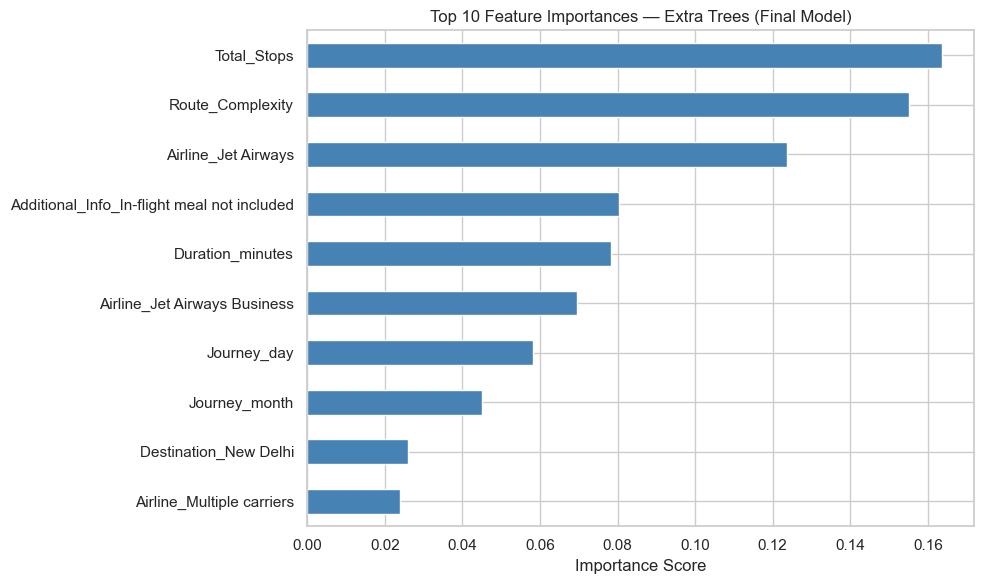

In [72]:
plt.figure(figsize=(10, 6))
feat_imp.plot(kind="barh", color="steelblue")
plt.title("Top 10 Feature Importances — Extra Trees (Final Model)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

******Route_Complexity, Airline_jet Airways and Duration_minutes are the most important features******

**Observation:**
- Total_Stops and Route_Complexity are top predictors.
- Airline_JetAirways and Duration_minutes also plays a major role.
- These match our EDA findings — strongly validates our
  feature engineering decisions.

# Actual vs Predicted Plot

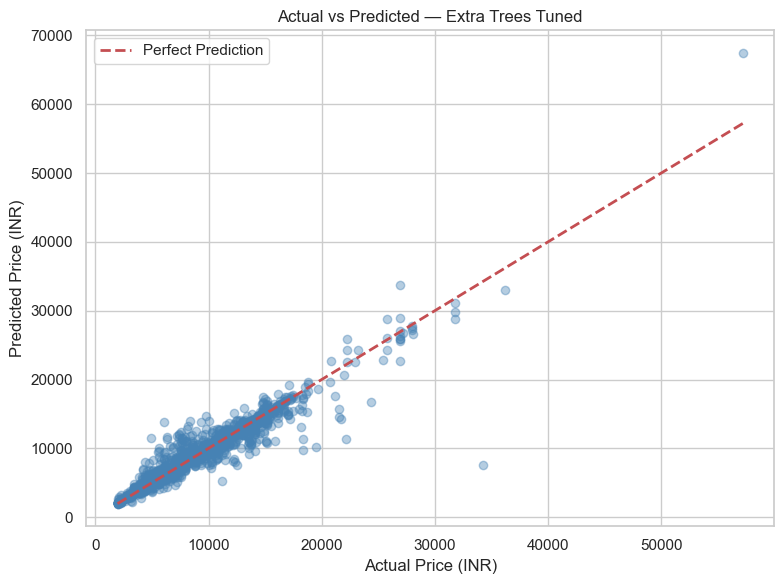

In [73]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_etr_tuned, alpha=0.4, color="steelblue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", linewidth=2, label="Perfect Prediction")
plt.xlabel("Actual Price (INR)")
plt.ylabel("Predicted Price (INR)")
plt.title("Actual vs Predicted — Extra Trees Tuned")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:**
- Majority of predictions are tightly clustered around the
  perfect prediction line — model is highly accurate for
  flights priced between Rs 2,000 to Rs 20,000.
- Predictions become less accurate for premium flights
  above Rs 30,000 due to very few high-price samples
  in the training data.
- One outlier visible at top right — likely a Business
  class ticket which the model has not seen enough of.
- Overall the model generalizes well on unseen test data.

## Residual Plot

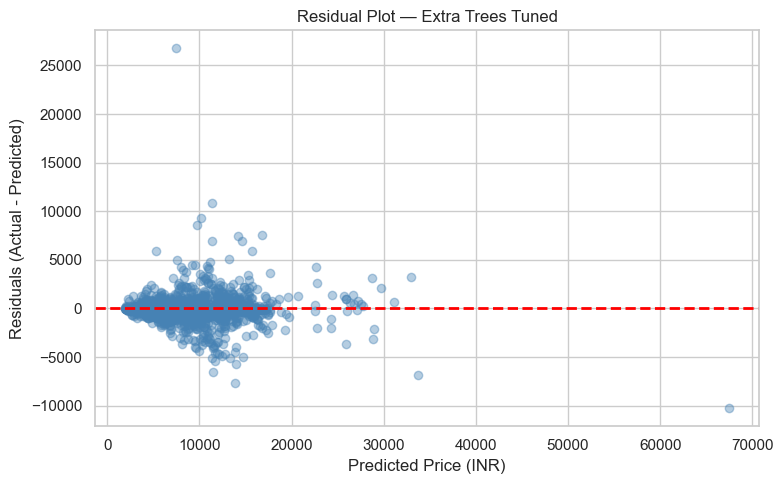

In [74]:
residuals = y_test - pred_etr_tuned

plt.figure(figsize=(8, 5))
plt.scatter(pred_etr_tuned, residuals, alpha=0.4, color="steelblue")
plt.axhline(y=0, color="red", linestyle="--", linewidth=2)
plt.xlabel("Predicted Price (INR)")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot — Extra Trees Tuned")
plt.tight_layout()
plt.show()

**Observation:**
- Residuals are randomly distributed around 0 — this is
  the ideal behavior for a regression model.
- No systematic pattern in residuals means the model
  is not biased towards over or under predicting.
- Large residuals visible only at extreme price points
  (above Rs 25,000) — these are rare premium tickets
  with insufficient training samples.
- The model performs consistently well across the
  majority of the price range.

## **Summary**

#### Actual vs Predicted and Residual plots confirm that the model predictions are reliable and unbiased for themajority of Indian domestic flight prices.

# Final Model Declaration

In [75]:
print("=" * 40)
print("       FINAL MODEL SELECTED")
print("=" * 40)
print(f"  Model   : Extra Trees Tuned")
print(f"  R2 Score: {r2_score(y_test, pred_etr_tuned):.4f}")
print(f"  MAE     : {mean_absolute_error(y_test, pred_etr_tuned):.2f}")
print(f"  RMSE    : {np.sqrt(mean_squared_error(y_test, pred_etr_tuned)):.2f}")
print(f"  CV R2   : {cv_scores.mean():.4f}")
print("=" * 40)

       FINAL MODEL SELECTED
  Model   : Extra Trees Tuned
  R2 Score: 0.9227
  MAE     : 598.16
  RMSE    : 1291.23
  CV R2   : 0.9081


---
## Report on Challenges Faced

**Challenge 1: Mixed Date/Time Formats**
- Problem: Arrival_Time had formats like `'01:10 22 Mar'` and `'13:15'`
- Solution: Used `errors='coerce'` to handle unparseable entries as NaT

**Challenge 2: Duration Mixed String Format**
- Problem: `'2h 50m'`, `'19h'`, `'45m'` — no consistent format
- Solution: Regex extraction for hours and minutes separately, filled missing with 0

**Challenge 3: Price Outliers**
- Dataset contained extreme price values up to Rs 79,512
  which are Business class and premium tickets.
- Decision: Outliers were intentionally kept in the dataset
  because tree based models like Extra Trees are naturally
  robust to outliers and removing them would cause the model
  to fail on real world premium ticket predictions.
  
**Challenge 4: High Cardinality Route Column**
- Problem: Hundreds of unique route strings — direct encoding not feasible
- Solution: Extracted Route_Complexity (city count) as numeric feature

**Challenge 5: Encoding Strategy**
- Problem: Multiple categorical columns needing different treatment
- Solution: Ordinal for Total_Stops (has order), One-Hot for rest (no order)

## Conclusion

### Project Summary
This project presents a complete end-to-end machine learning
pipeline to predict Indian domestic flight prices. The dataset
contained 10,683 records with 11 features covering multiple
airlines, routes, and travel dates across India.

### Data & Feature Engineering
- Handled missing values and 220 duplicate records
- Extracted meaningful features from raw date, time,
  and duration columns
- Created Route_Complexity feature from Route column
- Applied Ordinal Encoding to Total_Stops and One-Hot
  Encoding to all remaining categorical columns

### Model Performance Summary

| Model | R2 Score | RMSE |
|---|---|---|
| Extra Trees Tuned | 0.923 | 1290 |
| XGBoost Tuned | 0.917 | 1333 |
| Gradient Boosting Tuned | 0.900 | 1462 |
| Random Forest Tuned | 0.896 | 1493 |

### Final Model: Extra Trees Tuned
- R2 Score of 0.923 means model explains 92.3% of
  price variance on completely unseen test data
- Lowest RMSE of 1290 means average prediction
  error is only Rs 1,290
- Cross Validation confirmed model is stable and
  not overfitting

### Key Findings
- Total_Stops and Duration_minutes are the strongest
  price drivers — more stops and longer duration
  directly increase ticket price
- Airline type is a major factor — Jet Airways tickets
  are significantly more expensive than IndiGo or GoAir
- Summer months (May-June) show higher pricing trends
- Morning departure flights tend to be priced higher
  than night flights

### Limitations
- Dataset is limited to 2019 Indian domestic routes —
  model may not reflect current post-COVID pricing
- Premium and Business class tickets are underrepresented
  causing higher prediction error at extreme prices
- Model has not been tested on international routes

### Future Scope
- Add days-before-departure as a feature — booking
  in advance is a key real world pricing driver
- Collect more recent data (2023-2024) for current
  pricing patterns
- Deploy model as a web application using Flask or
  Streamlit for real time price predictions
- Try deep learning approaches like TabNet for
  potentially higher accuracy